In [59]:
from matplotlib import pyplot as plt
import seaborn as sns

import numpy as np

from PIL import Image
from skimage.color import rgb2lab

from sklearn.cluster import MeanShift, KMeans

from scipy.ndimage import median_filter

import pytesseract


path = "imgs/frame.jpeg"

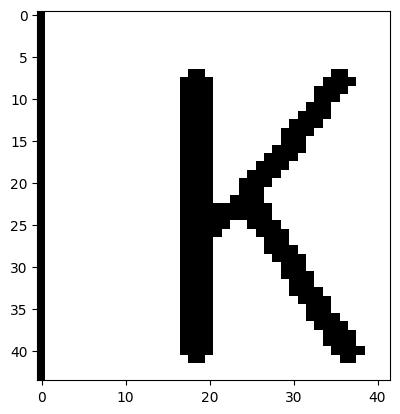

Found text: K


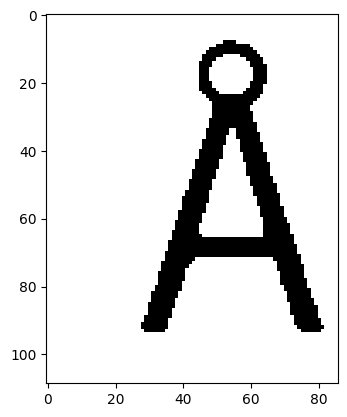

Found text: A


In [88]:
class WordfeudMap:
    def __init__(self, img_path):
        self.img = img
        self.board_offset  = 10
        self.tile_size     = img.shape[1]//15
        self.x = np.arange(15)*self.tile_size
        self.y = np.arange(15)*self.tile_size
        
        # Convert pixels to color labels
        self.colormap = {
            (41,44,49)    : 0, # board  background
            (234,233,222) : 1, # letter background
            (117,141,95)  : 2, # DL
            (53,97,138)   : 3, # TL
            (184,121,51)  : 4, # DW
            (130,52,49)   : 5, # TW
        }
        
        # Letter data
        self.letter_data = {
            "A": {"antal": 7, "point": 1}, "B": {"antal": 4, "point": 3}, "C": {"antal": 2, "point": 8},
            "D": {"antal": 5, "point": 2}, "E": {"antal": 9, "point": 1}, "F": {"antal": 3, "point": 3},
            "G": {"antal": 3, "point": 3}, "H": {"antal": 2, "point": 4}, "I": {"antal": 4, "point": 3},
            "J": {"antal": 2, "point": 4}, "K": {"antal": 4, "point": 3}, "L": {"antal": 5, "point": 2},
            "M": {"antal": 3, "point": 4}, "N": {"antal": 7, "point": 1}, "O": {"antal": 5, "point": 2},
            "P": {"antal": 2, "point": 4}, "R": {"antal": 7, "point": 1}, "S": {"antal": 6, "point": 2},
            "T": {"antal": 6, "point": 2}, "U": {"antal": 3, "point": 3}, "V": {"antal": 3, "point": 4},
            "X": {"antal": 1, "point": 8}, "Y": {"antal": 2, "point": 4}, "Z": {"antal": 1, "point": 9},
            "Æ": {"antal": 2, "point": 4}, "Ø": {"antal": 2, "point": 4}, "Å": {"antal": 2, "point": 4},
        }
        self.img = self.load_img(img_path)
    
    def load_img(self, img_path):
        # Crop to important part
        img = np.array(Image.open(img_path))[558:-250]

        # Make colors more consistent
        kmeans = KMeans(n_clusters=8, random_state=0).fit(img.reshape(-1, 3))
        quantized = kmeans.cluster_centers_[kmeans.labels_].astype(np.uint8)
        img = quantized.reshape(img.shape)
        
        return img
    
    def closest_color(self, rgb):
        min_dist = float('inf')
        closest = None
        for color in self.colormap.keys():
            dist = np.linalg.norm(np.array(rgb) - np.array(color))
            if dist < min_dist:
                min_dist = dist
                closest = color
        return self.colormap[closest]
    
    def img_to_map(self):
        # Define meshgrid
        X, Y = np.meshgrid(self.x, self.y)
        X += self.board_offset
        points = np.column_stack([Y.ravel(), X.ravel()])

        # Extract colors at tiles
        rows, cols = zip(*points)
        values = self.img[rows, cols, :].reshape(15,15,3)

        # Map values to closest color in colormap
        mapped = np.zeros((15,15), dtype=object)
        for i in range(15):
            for j in range(15):
                mapped[i,j] = self.closest_color(values[i,j])
                
        return mapped
        
    def tile_from_coord(self, xi, yi):
        tile = self.img[self.x[xi]:self.x[xi]+self.tile_size-self.board_offset, 
                        self.y[yi]:self.y[yi]+self.tile_size]
        return tile
    
    def available_letter_imgs(self):
        bottom_img = img[-155:-20,20:-20]

        letter_W = 130
        tile_W   = bottom_img.shape[1]//7

        letter_imgs = [bottom_img[:,letter_idx*tile_W:letter_idx*tile_W+letter_W] for letter_idx in range(7)]
        return letter_imgs
    
    def tile_to_text(self, tile):
        
        # crop to letter area
        H, W = tile.shape[:2]
        tile = tile[int(H*0.05):-int(H*0.15),:2*W//3,:]
        
        # convert letter to grayscale
        tile_gray = rgb2lab(tile)[:,:,0]
        
        # threhsolding
        tile_gray = (tile_gray < 10).astype(np.uint8)*255
        tile_gray = 255 - tile_gray
        
        # median filter to remove noise
        tile_gray = median_filter(tile_gray, size=3)
        
        plt.imshow(tile_gray, cmap='gray');
        plt.show()
        
        text = pytesseract.image_to_string(tile_gray, lang='eng+dan', config='--psm 10')
        if not text:
            print("No text found, trying without processing...")
        else:
            print(f"Found text: {text.strip()}")
    
WF = WordfeudMap(path)
mapped = WF.img_to_map()
tile = WF.tile_from_coord(6,6)
WF.tile_to_text(tile)

letter_imgs = WF.available_letter_imgs()
WF.tile_to_text(letter_imgs[2])


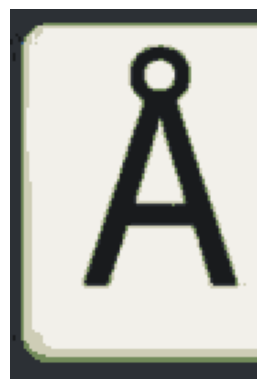

In [36]:
# Get any stored letter
bottom_img = img[-155:-20,20:-20]

letter_W = 90
tile_W   = bottom_img.shape[1]//7
letter_idx = 2

letter = bottom_img[:,letter_idx*tile_W:letter_idx*tile_W+letter_W]
plt.imshow(letter)
plt.axis('off')
plt.show()


Found text: Å


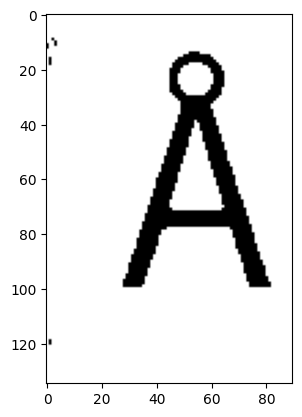

In [ ]:
import pytesseract

# convert letter to grayscale
letter_proc = rgb2lab(letter)[:,:,0]
# threhsolding
letter_proc = (letter_proc < 10).astype(np.uint8)*255
letter_proc = 255 - letter_proc
plt.imshow(letter_proc, cmap='gray');


text = pytesseract.image_to_string(letter_proc, lang='dan', config='--psm 10')
if not text:
    print("No text found, trying without processing...")
else:
    print(f"Found text: {text.strip()}")